In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import jax
import jax.numpy as jnp 
import jax.random as jr
import lineax as lx
import diffrax as dx
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np

For the ODE 2d equations this is gonna be for two examples 

Harmonic Ocilator 

$$ m \frac{d^2u}{dt^2} + \mu \frac{du}{dt} + ku = 0$$


Van der Pol Ocilator 

$$ \frac{d^2}{dt^2} - \mu(1-u^2) \frac{du}{dt} + u = 0 $$

For the harmonic ocilator we take $ v = \frac{du}{dt} $ and then isolate the expression as terms of $v$

$$ \frac{du}{dt} = \frac{-u}{m} \cdot v - \frac{ku}{m} $$

In [70]:
#@jax.jit
def simulate_harm_ocilator(m, mu, k, u0, v0, t0, t1):
    
    def vec_field(t,y,args):
        u, v = y
        
        du_dt = v 
        dv_dt = -(mu / m) * v - (k / m) * u
        
        return jnp.stack([du_dt, dv_dt])
    
    terms = dx.ODETerm(vector_field=vec_field)
    solver = dx.Tsit5()
    
    y0_state = jnp.array([u0, v0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0, t1, 1000), dense=True)
    
    sol = dx.diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=y0_state, saveat=saveat, max_steps=16384)
    return sol 



shape (1000, 2)


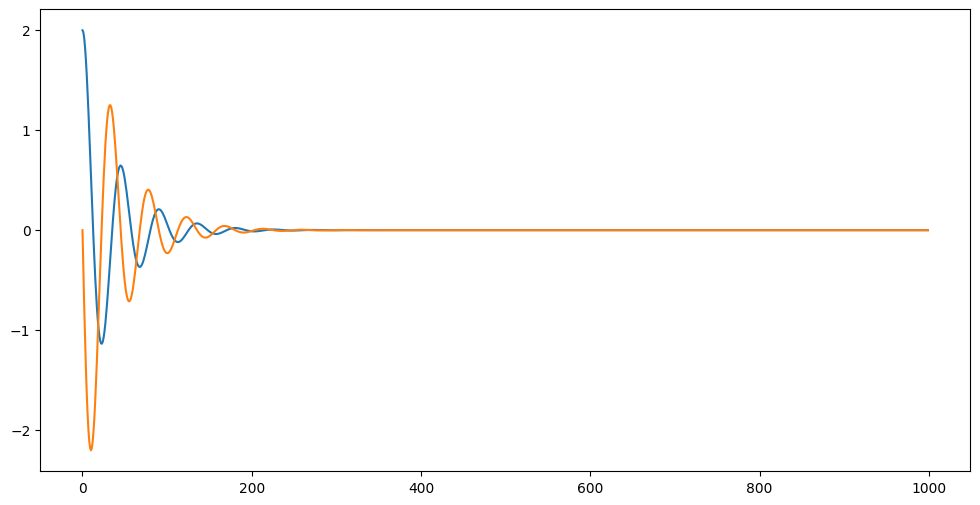

In [72]:
sol = simulate_harm_ocilator(m=1.0, mu=0.5, k=2.0, u0=2.0, v0=0.0, t0=0.0, t1=100.0)
print(f"shape {sol.ys.shape}")
#print(f"Solution for t0: {sol.t0}")
#print(f"Solution for t1: {sol.t1}")
#print(f"Solution for ys: {sol.ys}")
#print(f"Solution for ts {sol.ts}")

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(sol.ys)


#fig, ax = plt.subplots(figsize=(12,6))
#ax.plot(sol.ts)

In [4]:
def van_de_paul(mu, u0, v0, t0, t1, size):
    
    def vec_field(t, y, args):
        u,v = y
        du_dt = v
        
        dv_dt = mu * (1 - u**2) * v - u
        
        return jnp.stack([du_dt,dv_dt])
    
    terms = dx.ODETerm(vector_field=vec_field)
    solver = dx.Tsit5()
    
    y0_state = jnp.array([u0, v0])
    saveat = dx.SaveAt(ts=jnp.linspace(t0,t1,size), dense=True)
    
    sol = dx.diffeqsolve(
        terms,
        solver,
        t0,
        t1,
        dt0=0.01,
        y0=y0_state,
        saveat=saveat,
        args=mu
    )
    
    return sol

In [5]:
sol = van_de_paul(mu=2.0, u0=0.2, v0=0.0, t0=0.0, t1=20.0, size=1000)
print(f"shape {sol.ys.shape}")
#print(f"Solution for t0: {sol.t0}")
#print(f"Solution for t1: {sol.t1}")
#print(f"Solution for ys: {sol.ys}")
#print(f"Solution for ts {sol.ts}")



shape (1000, 2)


------------------------------
    Van der Pol Simulation    
------------------------------
Time Range:  0.0 to 20.0
State Shape: (1000, 2) (Timepoints, Variables)
Final State: u = 1.4197, v = 3.2661
Status:      Success
------------------------------


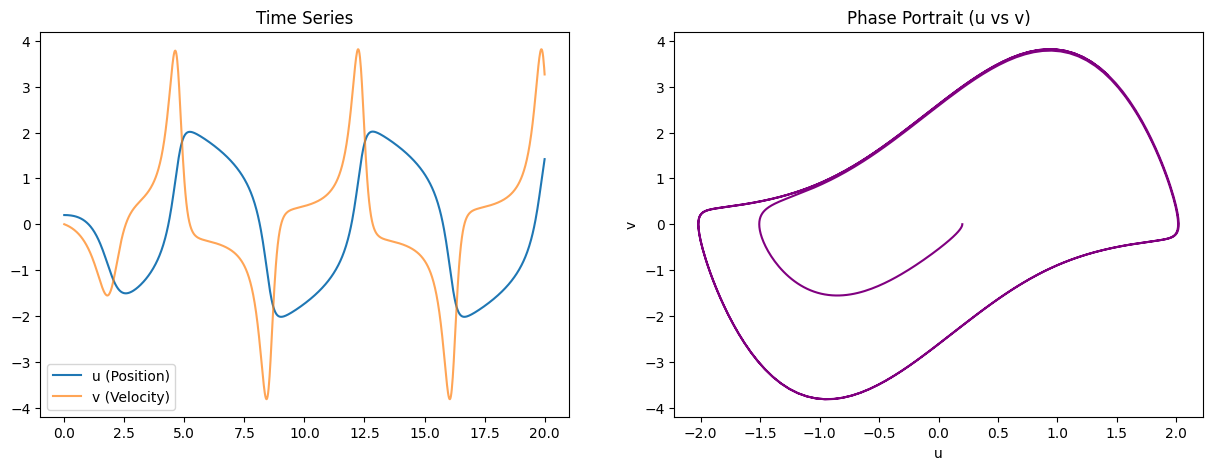

In [6]:
def print_summary(sol):
    print("-" * 30)
    print(f"{'Van der Pol Simulation':^30}")
    print("-" * 30)
    print(f"Time Range:  {sol.t0} to {sol.t1}")
    print(f"State Shape: {sol.ys.shape} (Timepoints, Variables)")
    print(f"Final State: u = {sol.ys[-1, 0]:.4f}, v = {sol.ys[-1, 1]:.4f}")
    print(f"Status:      {'Success' if sol.result == dx.RESULTS.successful else 'Failed'}")
    print("-" * 30)

print_summary(sol)

# Visualizing Position vs Time AND the Phase Portrait
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Time Series
ax1.plot(sol.ts, sol.ys[:, 0], label="u (Position)")
ax1.plot(sol.ts, sol.ys[:, 1], label="v (Velocity)", alpha=0.7)
ax1.set_title("Time Series")
ax1.legend()

# 2. Phase Portrait (u vs v)
# This shows the "Limit Cycle"
ax2.plot(sol.ys[:, 0], sol.ys[:, 1], color='purple')
ax2.set_title("Phase Portrait (u vs v)")
ax2.set_xlabel("u")
ax2.set_ylabel("v")

plt.show()

Here we notice that the van de pol is not the best to outfit in a predictive path so, we gonna continue as the normal harmonit pendulum

shape (1000, 2)


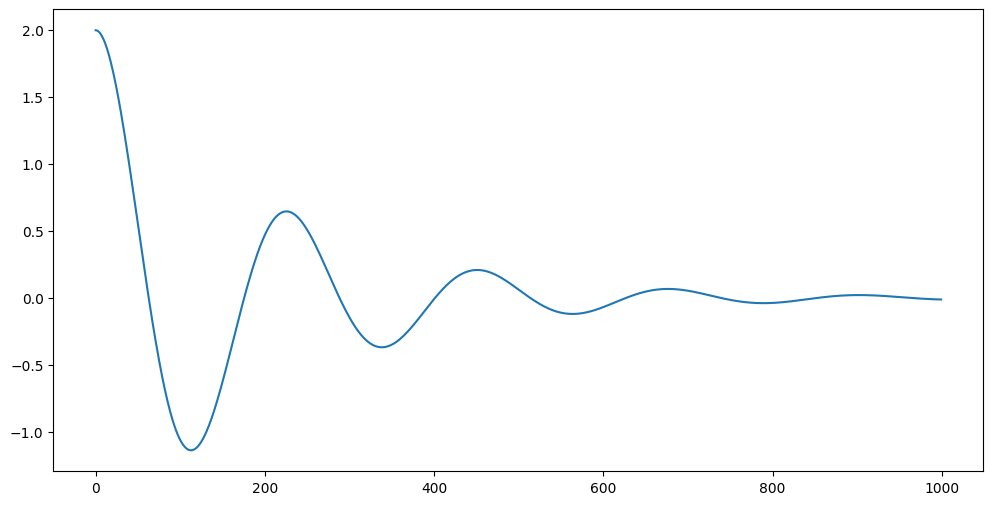

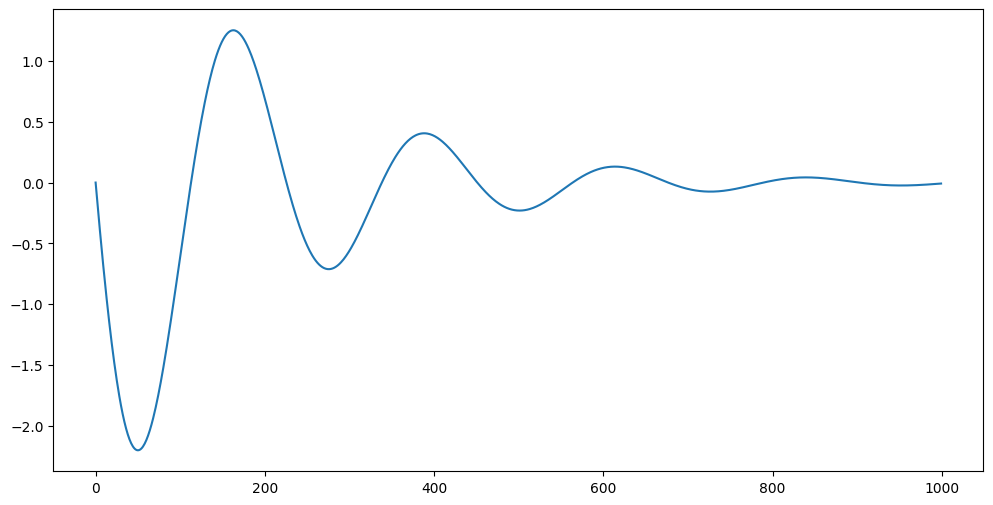

In [15]:
sol = simulate_harm_ocilator(m=1.0, mu=0.5, k=2.0, u0=2.0, v0=0.0, t0=0.0, t1=20.0)
print(f"shape {sol.ys.shape}")
#print(f"Solution for t0: {sol.t0}")
#print(f"Solution for t1: {sol.t1}")
#print(f"Solution for ys: {sol.ys}")
#print(f"Solution for ts {sol.ts}")

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(sol.ys[:, 0])

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(sol.ys[:, 1:2])
# Here is the analitical solution 

#fig, ax = plt.subplots(figsize=(12,6))
#ax.plot(sol.ts)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [80]:
class Net(nn.Module):
    def __init__(self, u0, v0):
        super(Net, self).__init__()
        # Store the initial conditions
        self.u0 = u0
        self.v0 = v0
        
        # F(t) -> u, v
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        
    def forward(self, t):
        # 1. Pass time 't' through the network
        x = torch.sin(self.fc1(t))
        x = torch.sin(self.fc2(x))
        raw_out = self.fc3(x)
        
        # Split raw output into raw_u and raw_v
        u_nn = raw_out[:, 0:1]
        v_nn = raw_out[:, 1:2]
        
        # 2. Apply the Hard Constraint (Ansatz)
        # Because we multiply by 't', when t=0, the NN part becomes 0.
        # This guarantees that at t=0, u_pred = u0 and v_pred = v0 exactly!
        u_pred = self.u0 + t * u_nn
        v_pred = self.v0 + t * v_nn
        
        # 3. Combine back together
        return torch.cat([u_pred, v_pred], dim=1)


In [81]:
### LOSS FUNCTION
def phy_loss(model, t_coll, m=2.0 , mu= 0.5, k=1.0):
    
    t_coll.requires_grad = True

    preds = model(t_coll)
    u = preds[:, 0:1] # -> u(t)
    v = preds[:, 1:2] # -> v(t)

    du_dt = torch.autograd.grad( # du/dt
        u, t_coll,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    
    dv_dt = torch.autograd.grad(
        v, t_coll,
        grad_outputs=torch.ones_like(v),
        create_graph=True,
        retain_graph=True
    )[0]
    
    resi_1 = du_dt - v
    resi_2 = dv_dt + (mu / m) * v + (k / m) * u
    
    return torch.mean(resi_1**2) + torch.mean(resi_2**2)

def loss_ic(model, u0, v0):
    t0 = torch.tensor([[0.0]], requires_grad=True).to(device)
    # print(f"t0: {t0} and {t0.device}")
    preds = model(t0)
    u_pred = preds[:, 0:1]
    v_pred = preds[:, 1:2]
    
    loss_u = torch.mean( ( u_pred - u0) ** 2)
    loss_v = torch.mean( ( v_pred - v0) ** 2)
    
    return loss_u + loss_v


In [84]:
def output_data(size, steps):
    
    t_coll = torch.linspace(0, size, steps).unsqueeze(1)
    u_coll = sol.ys[:, 0]
    v_coll = sol.ys[:, 1]
    
    return t_coll, u_coll, v_coll


def train(seed=42, epochs=5000, lr=1e-3, device=device):
    
    torch.manual_seed(seed)
    v0 = torch.tensor([10.0], requires_grad=True, device=device)
    u0 = torch.tensor([0.0], requires_grad=True, device=device)
    
    model = Net(u0, v0).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    
    t_coll = torch.linspace(0, 10, 1000, device=device).view(-1, 1)
    
    for e in range(epochs):
        optim.zero_grad()
        
        t_coll.requires_grad_(True)
        loss_ode = loss = phy_loss(model, t_coll, m=2.0, mu=0.5, k=1.0)
        loss = loss_ode
        loss.backward()
        
        optim.step()
        
        t_coll = t_coll.detach()
        
        if e % 500 == 0:
            print(f"Epoch {e} - Loss: {loss.item():.6f} (ODE: {loss_ode.item():.6f}")
            
    return model

In [85]:
t_data, u_data, v_data = output_data(size=10.0, steps=1000)

t_data = np.array(t_data, copy=True)
#u_data = np.array(u_data, copy=True)
#v_data = np.array(v_data, copy=True)

# Convert to torch tensors
t_data = torch.tensor(t_data, dtype=torch.float32, device=device)
#u_data = torch.tensor(u_data, dtype=torch.float32, device=device)
#v_data = torch.tensor(v_data, dtype=torch.float32, device=device)


train_model = train(seed=42, epochs=50000, lr=1e-4, device=device)

/tmp/ipykernel_19244/2303347433.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  t_data = np.array(t_data, copy=True)


Epoch 0 - Loss: 169.956955 (ODE: 169.956955
Epoch 500 - Loss: 19.072008 (ODE: 19.072008
Epoch 1000 - Loss: 8.058492 (ODE: 8.058492
Epoch 1500 - Loss: 4.051805 (ODE: 4.051805
Epoch 2000 - Loss: 2.347023 (ODE: 2.347023
Epoch 2500 - Loss: 1.415329 (ODE: 1.415329
Epoch 3000 - Loss: 0.836427 (ODE: 0.836427
Epoch 3500 - Loss: 0.482593 (ODE: 0.482593
Epoch 4000 - Loss: 0.274323 (ODE: 0.274323
Epoch 4500 - Loss: 0.153722 (ODE: 0.153722
Epoch 5000 - Loss: 0.085265 (ODE: 0.085265
Epoch 5500 - Loss: 0.049028 (ODE: 0.049028
Epoch 6000 - Loss: 0.030177 (ODE: 0.030177
Epoch 6500 - Loss: 0.019435 (ODE: 0.019435
Epoch 7000 - Loss: 0.012803 (ODE: 0.012803
Epoch 7500 - Loss: 0.008554 (ODE: 0.008554
Epoch 8000 - Loss: 0.005744 (ODE: 0.005744
Epoch 8500 - Loss: 0.003810 (ODE: 0.003810
Epoch 9000 - Loss: 0.002486 (ODE: 0.002486
Epoch 9500 - Loss: 0.001667 (ODE: 0.001667
Epoch 10000 - Loss: 0.001185 (ODE: 0.001185
Epoch 10500 - Loss: 0.000826 (ODE: 0.000826
Epoch 11000 - Loss: 0.000642 (ODE: 0.000642
Epoch 

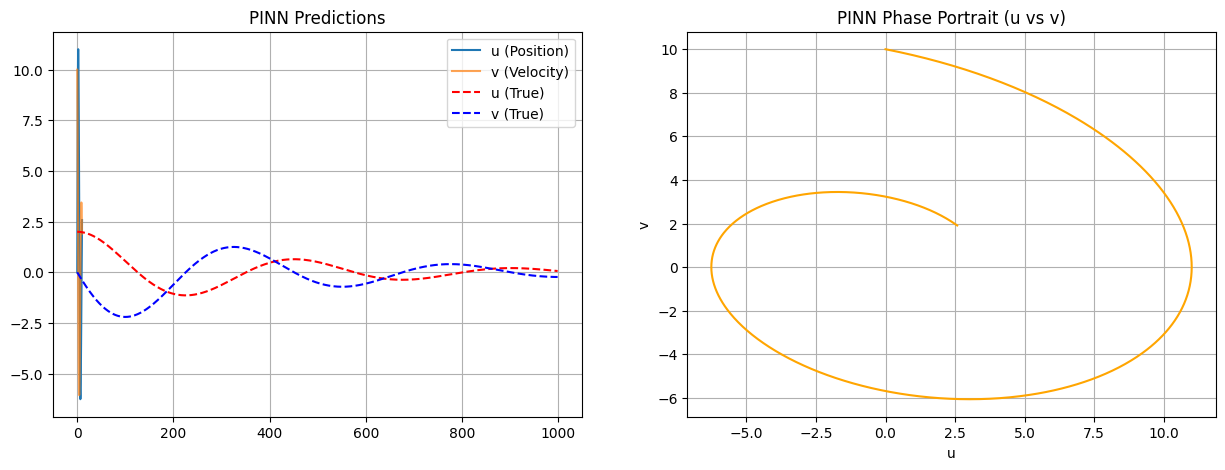

In [86]:
train_model.eval()

sol = simulate_harm_ocilator(m=1.0, mu=0.5, k=2.0, u0=2.0, v0=0.0, t0=0.0, t1=10.0)

with torch.no_grad():
    t_test = torch.linspace(0, 10.0, 1000).unsqueeze(1).to(device)
    preds = train_model(t_test)
    u_pred = preds[:, 0].cpu().numpy()
    v_pred = preds[:, 1].cpu().numpy()
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(t_test.cpu().numpy(), u_pred, label="u (Position)")
ax1.plot(t_test.cpu().numpy(), v_pred, label="v (Velocity)", alpha=0.7)
ax1.plot(sol.ys[:, 0], label="u (True)", linestyle='dashed', color='red')
ax1.plot(sol.ys[:, 1], label="v (True)", linestyle='dashed', color='blue')
ax1.set_title("PINN Predictions")
ax1.legend()
ax1.grid()

ax2.plot(u_pred, v_pred, color='orange')
ax2.set_title("PINN Phase Portrait (u vs v)")
ax2.set_xlabel("u")
ax2.set_ylabel("v")
ax2.grid()

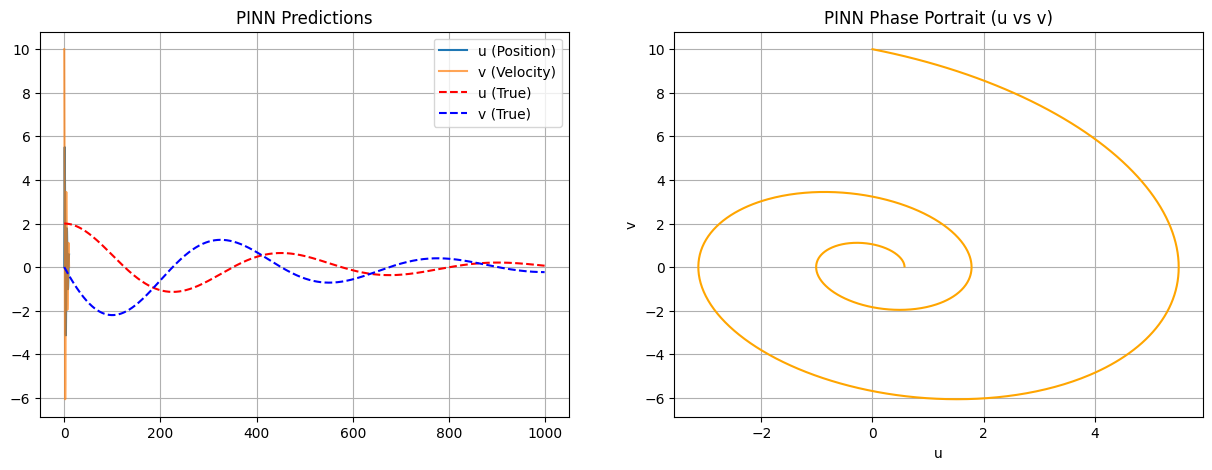

In [79]:
train_model.eval()

sol = simulate_harm_ocilator(m=1.0, mu=0.5, k=2.0, u0=2.0, v0=0.0, t0=0.0, t1=10.0)

with torch.no_grad():
    t_test = torch.linspace(0, 10.0, 1000).unsqueeze(1).to(device)
    preds = train_model(t_test)
    u_pred = preds[:, 0].cpu().numpy()
    v_pred = preds[:, 1].cpu().numpy()
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(t_test.cpu().numpy(), u_pred, label="u (Position)")
ax1.plot(t_test.cpu().numpy(), v_pred, label="v (Velocity)", alpha=0.7)
ax1.plot(sol.ys[:, 0], label="u (True)", linestyle='dashed', color='red')
ax1.plot(sol.ys[:, 1], label="v (True)", linestyle='dashed', color='blue')
ax1.set_title("PINN Predictions")
ax1.legend()
ax1.grid()

ax2.plot(u_pred, v_pred, color='orange')
ax2.set_title("PINN Phase Portrait (u vs v)")
ax2.set_xlabel("u")
ax2.set_ylabel("v")
ax2.grid()

TODO -> tomorow or in today sunday 

The next is gonna be Fokker-Planck equation 

Or SPINNs